# SUPR full body — what the parameters actually do

Same playground as `playground.ipynb` and `playground_full_lowerleg.ipynb`, now for the whole
body: **75 joints, 225 pose numbers, 10475 vertices**.

Two things follow from the size.

225 sliders is not a user interface, so instead you pick a joint from a dropdown and move its
three axes. Your choices accumulate, so you can build a pose one joint at a time. A
*symmetric* switch mirrors whatever you do onto the other side.

Left and right do **not** take the same sign. Pitch does, but yaw and roll are mirrored --
`shoulder_L_roll = -45` lowers the left arm and `shoulder_R_roll = -45` *raises* the right one.
The `mirror()` helper handles that so you do not have to remember it.

Units are millimetres. The model is in metres, so that conversion is exact.

The neutral body is a **T-pose**: arms straight out, 1719.9 mm tall.

## 1 — Setup

In [1]:
import os, sys
os.environ["CUDA_VISIBLE_DEVICES"] = "1"          # pick any free GPU

REPO = "/storage/Abhinay/Shell_Gaussian/baselines/SUPR"
if REPO not in sys.path:
    sys.path.insert(0, REPO)

import numpy as np, torch
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import trimesh
from trimesh.intersections import mesh_plane
from matplotlib.collections import PolyCollection
from supr.pytorch.supr import SUPR

NUM_BETAS = 100      # the file holds 400; 100 is plenty
UNIT_MM   = 1000.0   # the model is in metres -- exact, not an anchor
DEVICE    = "cuda" if torch.cuda.is_available() else "cpu"

BODY_NPY = f"{REPO}/data/supr_neutral.npy"
model = SUPR(BODY_NPY, num_betas=NUM_BETAS)
FACES = np.asarray(model.f.detach().cpu().numpy() if torch.is_tensor(model.f) else model.f,
                   np.int64)

print(f"device {DEVICE} | {model.num_joints} joints | {model.num_pose} pose numbers | "
      f"{model.num_verts} vertices | {len(FACES)} triangles")
print("SUPR only publishes male models, so this is the one body we have.")

device cuda | 75 joints | 225 pose numbers | 10475 vertices | 20908 triangles
SUPR only publishes male models, so this is the one body we have.


## 2 — The kit

`body(shoulder_L_roll=-45)` poses it. `report` prints anthropometrics in mm, `show` draws flat
views, `make_view` gives you a rotatable 3D one.

Girths are measured on the **T-pose** body with your current betas, never on the posed one.
A chest circumference is a property of the body, not of what it is doing, and measuring it on
a posed body would slice through the arms.

In [2]:
# ---- the 75 joints, named -------------------------------------------------------
JOINTS = {
    "pelvis": 0, "spine1": 3, "spine2": 6, "spine3": 9, "neck": 12, "head": 15,
    "jaw": 22, "eye_L": 23, "eye_R": 24,
    "hip_L": 1, "hip_R": 2, "knee_L": 4, "knee_R": 5,
    "ankle_L": 7, "ankle_R": 8, "foot_L": 10, "foot_R": 11,
    "collar_L": 13, "collar_R": 14, "shoulder_L": 16, "shoulder_R": 17,
    "elbow_L": 18, "elbow_R": 19, "wrist_L": 20, "wrist_R": 21,
}
# hands: SMPL-X order is index, middle, pinky, ring, thumb -- three joints each
for side, base in (("L", 25), ("R", 40)):
    for k, finger in enumerate(("index", "middle", "pinky", "ring", "thumb")):
        for seg, part in enumerate(("1", "2", "3")):
            JOINTS[f"{finger}{part}_{side}"] = base + 3 * k + seg
# toes: SUPR's own addition -- two joints each, medial to lateral
for side, base in (("L", 55), ("R", 65)):
    for k, toe in enumerate(("big_toe", "toe2", "toe3", "toe4", "little_toe")):
        for seg, part in enumerate(("", "_tip")):
            JOINTS[f"{toe}{part}_{side}"] = base + 2 * k + seg

assert len(JOINTS) == 75 and sorted(JOINTS.values()) == list(range(75))
NAME_OF = {v: k for k, v in JOINTS.items()}

AXES = {"pitch": 0, "yaw": 1, "roll": 2}
# Rotations about X read the same on both sides; about Y and Z they mirror.
MIRRORED_AXES = ("yaw", "roll")

BIG_JOINTS = ("spine1", "spine2", "spine3", "neck", "head",
              "shoulder_L", "shoulder_R", "elbow_L", "elbow_R", "wrist_L", "wrist_R",
              "hip_L", "hip_R", "knee_L", "knee_R", "ankle_L", "ankle_R")

DESC = {"pelvis": "the root -- moves everything; leave at 0",
        "spine1": "lower back", "spine2": "mid back", "spine3": "chest",
        "neck": "neck", "head": "head", "jaw": "jaw", 
        "shoulder_L": "the arm points along X, so PITCH is a twist and roll/yaw swing it",
        "elbow_L": "same -- roll bends it upward, yaw bends it forward",
        "hip_L": "pitch swings the leg back (+), roll takes it sideways",
        "knee_L": "pitch (+) folds the heel back", "ankle_L": "pitch (+) points the toes"}

def mirror(joint_stem, axis, degrees):
    """mirror('shoulder', 'roll', -45) -> both arms down, signs handled for you."""
    flip = -1.0 if axis in MIRRORED_AXES else 1.0
    return {f"{joint_stem}_L_{axis}": degrees,
            f"{joint_stem}_R_{axis}": degrees * flip}

RECIPES = {
    "T-pose (neutral)":   {},
    "A-pose":             {**mirror("shoulder", "roll", -45)},
    "arms at sides":      {**mirror("shoulder", "roll", -72)},
    "arms straight up":   {**mirror("shoulder", "roll", 78)},
    "arms forward":       {**mirror("shoulder", "yaw", -80)},
    "elbows bent":        {**mirror("shoulder", "roll", -55), **mirror("elbow", "roll", 80)},
    "sitting":            {**mirror("hip", "pitch", -85), **mirror("knee", "pitch", 85),
                           **mirror("shoulder", "roll", -60)},
    "deep squat":         {**mirror("hip", "pitch", -95), **mirror("knee", "pitch", 115),
                           **mirror("shoulder", "roll", -55), "spine2_pitch": -20},
    "walking stride":     {"hip_L_pitch": -28, "hip_R_pitch": 22,
                           "knee_L_pitch": 12, "knee_R_pitch": 40,
                           **mirror("shoulder", "roll", -62)},
    "leaning forward":    {"spine1_pitch": 25, "spine2_pitch": 20,
                           **mirror("shoulder", "roll", -60)},
    "legs apart":         {**mirror("hip", "roll", 22)},
}

def body(betas=None, **angles):
    """body(hip_L_pitch=-85, knee_L_pitch=85) -- angles in DEGREES.

    Returns (vertices (10475,3), joints (75,3))."""
    pose = torch.zeros((1, model.num_pose), dtype=torch.float32, device=DEVICE)
    for key, deg in angles.items():
        joint, _, axis = key.rpartition("_")
        if joint not in JOINTS or axis not in AXES:
            raise KeyError(f"{key!r}: expected <joint>_<axis>. "
                           f"axes={sorted(AXES)}; see sorted(JOINTS) for joint names")
        pose[0, JOINTS[joint] * 3 + AXES[axis]] = np.deg2rad(deg)
    b = torch.zeros((1, NUM_BETAS), dtype=torch.float32, device=DEVICE)
    for i, v in (betas or {}).items():
        b[0, i] = v
    t = torch.zeros((1, 3), dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        out = model.forward(pose, b, t)
    return out[0].cpu().numpy(), out.J_transformed[0].cpu().numpy()

NEUTRAL, NEUTRAL_J = body()

# ---- measurement ---------------------------------------------------------------
def _section_girth(V, y, keep=None):
    """Exact perimeter where a horizontal plane cuts the body.

    10475 vertices is plenty, but binning vertices still misreads a curved surface, so the
    triangles are intersected with the plane directly. `keep` filters segments by their
    midpoint, which is how one leg is measured without also catching the other."""
    mesh = trimesh.Trimesh(vertices=V, faces=FACES, process=False)
    seg = np.asarray(mesh_plane(mesh, plane_normal=np.array([0.0, 1.0, 0.0]),
                                plane_origin=np.array([0.0, y, 0.0])))
    if seg.size == 0:
        return np.nan
    if keep is not None:
        mid = seg.mean(axis=1)
        seg = seg[keep(mid)]
        if seg.size == 0:
            return np.nan
    return float(np.linalg.norm(seg[:, 1] - seg[:, 0], axis=1).sum()) * UNIT_MM

RIGHT = lambda p: p[:, 0] < 0.0          # the right half, matching the leg notebook

def _stations(J):
    """Where each girth is taken, anchored to joints so it follows the body's shape."""
    hip, knee, ankle = J[JOINTS["hip_R"]][1], J[JOINTS["knee_R"]][1], J[JOINTS["ankle_R"]][1]
    # halfway from the neck joint to the head: at the joint itself the plane still
    # catches the slope of the shoulders and reads about 7 cm too big.
    neck = 0.5 * (J[JOINTS["neck"]][1] + J[JOINTS["head"]][1])
    return {"neck":   (neck,                   None),
            "chest":  (J[JOINTS["spine3"]][1], None),
            "waist":  (J[JOINTS["spine1"]][1], None),
            "hip":    (J[JOINTS["pelvis"]][1] - 0.035, None),
            "thigh":  (hip + 0.18 * (knee - hip), RIGHT),
            "calf":   (knee + 0.30 * (ankle - knee), RIGHT),
            "ankle":  (ankle + 0.06 * (knee - ankle), RIGHT)}

def measure(V, joints=None, betas=None):
    """Anthropometrics in mm. Girths come from the T-pose body with the same betas."""
    J = joints if joints is not None else NEUTRAL_J
    Vt, Jt = body(betas=betas)                     # T-pose, same shape
    g = {name: _section_girth(Vt, y, keep) for name, (y, keep) in _stations(Jt).items()}
    bone = lambda a, b: float(np.linalg.norm(J[JOINTS[a]] - J[JOINTS[b]]) * UNIT_MM)
    return {"stature_mm":       float(np.ptp(Vt[:, 1]) * UNIT_MM),
            "bbox_height_mm":   float(np.ptp(V[:, 1]) * UNIT_MM),
            "arm_span_mm":      float(np.ptp(Vt[:, 0]) * UNIT_MM),
            "shoulder_w_mm":    bone("shoulder_L", "shoulder_R"),
            "arm_mm":           bone("shoulder_R", "elbow_R") + bone("elbow_R", "wrist_R"),
            "leg_mm":           bone("hip_R", "knee_R") + bone("knee_R", "ankle_R"),
            **{f"{k}_girth_mm": v for k, v in g.items()},
            **_distortion(V)}

def _distortion(V):
    T  = V[FACES];       n  = np.cross(T[:, 1] - T[:, 0], T[:, 2] - T[:, 0])
    T0 = NEUTRAL[FACES]; n0 = np.cross(T0[:, 1] - T0[:, 0], T0[:, 2] - T0[:, 0])
    r = np.linalg.norm(n, axis=1) / np.maximum(np.linalg.norm(n0, axis=1), 1e-12)
    return {"torn_triangles": int((np.einsum("ij,ij->i", n, n0) < 0).sum()),
            "stretch_p99": float(np.percentile(r, 99)), "stretch_max": float(r.max()),
            "stretched_triangles": int((r > 1.5).sum()), "triangle_count": int(len(r))}

def report(V, label="", joints=None, betas=None):
    m = measure(V, joints, betas)
    print(f"{label:22s} stature {m['stature_mm']:6.1f} | span {m['arm_span_mm']:6.1f} | "
          f"chest {m['chest_girth_mm']:5.1f} | waist {m['waist_girth_mm']:5.1f} | "
          f"hip {m['hip_girth_mm']:5.1f} mm | stretch {m['stretch_p99']:.2f}x "
          f"({m['stretched_triangles']}/{m['triangle_count']} tris over 1.5x)"
          + ("  TORN" if m["torn_triangles"] else ""))
    return m

def girth_profile(V, slices=40, lo=0.02, hi=0.78):
    """Girth up the body, as a fraction of stature. Stops below the armpits, because a
    horizontal cut at shoulder height slices the arms too."""
    y0, y1 = V[:, 1].min(), V[:, 1].max(); span = y1 - y0
    rows = []
    for f in np.linspace(lo, hi, slices):
        per = _section_girth(V, y0 + f * span)
        if np.isfinite(per):
            rows.append(((y0 + f * span - y0) * UNIT_MM, per))
    return np.asarray(rows)

# ---- flat views ----------------------------------------------------------------
VIEWS = {"front": (0, 1), "side": (2, 1), "top": (0, 2)}
VIEW_LABEL = {"front": "front", "side": "side (facing +Z)", "top": "from above"}

def show(*bodies, view="front", labels=None, ghost=False, figsize=None, pad=0.03):
    """show(NEUTRAL, posed, labels=['T-pose','sitting'], ghost=True)

    20908 triangles per panel, so this takes a second or two. The frame is fitted to
    everything drawn and all panels share one scale."""
    labels = labels or [f"body {i+1}" for i in range(len(bodies))]
    a, b = VIEWS[view]
    other = [i for i in (0, 1, 2) if i not in (a, b)][0]
    shown = list(bodies) + ([NEUTRAL] if ghost else [])
    lo_a = min(V[:, a].min() for V in shown); hi_a = max(V[:, a].max() for V in shown)
    lo_b = min(V[:, b].min() for V in shown); hi_b = max(V[:, b].max() for V in shown)
    p = pad * max(hi_a - lo_a, hi_b - lo_b) + 1e-9
    ca, cb = (lo_a + hi_a) / 2, (lo_b + hi_b) / 2
    half_a, half_b = (hi_a - lo_a) / 2 + p, (hi_b - lo_b) / 2 + p
    h = figsize[1] if figsize else 4.2 * max(1.0, half_b / half_a)
    fig, axes = plt.subplots(1, len(bodies), figsize=figsize or (3.0 * len(bodies), h),
                             squeeze=False)
    for ax, V, lab in zip(axes[0], bodies, labels):
        if ghost:
            T = NEUTRAL[FACES][:, :, [a, b]]
            o = np.argsort(NEUTRAL[FACES][:, :, other].mean(axis=1))
            ax.add_collection(PolyCollection(T[o], facecolors="#0000000D",
                                             edgecolors="none", zorder=1))
        T = V[FACES][:, :, [a, b]]
        o = np.argsort(V[FACES][:, :, other].mean(axis=1))
        ax.add_collection(PolyCollection(T[o], facecolors="#5B7FA6",
                                         edgecolors="none", zorder=2))
        ax.set_title(lab, fontsize=10.5)
        ax.set_xlim(ca - half_a, ca + half_a); ax.set_ylim(cb - half_b, cb + half_b)
        ax.set_aspect("equal"); ax.axis("off")
    fig.suptitle(VIEW_LABEL[view], fontsize=9, y=1.0)
    fig.tight_layout()
    return fig

# ---- 3D view -------------------------------------------------------------------
def _xyz(V):
    """Model raw (x=width, y=up, z=forward) -> plot (x=forward, y=width, z=up)."""
    return V[:, 2], V[:, 0], V[:, 1]

def make_view(V, height=680, skeleton=True):
    """A rotatable 3D body. Drag to spin, scroll to zoom, right-drag to pan."""
    x, y, z = _xyz(V)
    data = [go.Mesh3d(x=x, y=y, z=z, i=FACES[:, 0], j=FACES[:, 1], k=FACES[:, 2],
                      color="#5B7FA6", flatshading=False, hoverinfo="skip",
                      lighting=dict(ambient=.45, diffuse=.85, specular=.15, roughness=.85),
                      lightposition=dict(x=200, y=-200, z=300))]
    if skeleton:
        data.append(go.Scatter3d(x=[], y=[], z=[], mode="lines",
                                 line=dict(width=3, color="#C0442A"), hoverinfo="skip"))
    fig = go.FigureWidget(data=data)
    fig.update_layout(height=height, margin=dict(l=0, r=0, t=0, b=0), showlegend=False,
        scene=dict(aspectmode="data",
                   xaxis=dict(title="forward", showbackground=False, showticklabels=False),
                   yaxis=dict(title="width", showbackground=False, showticklabels=False),
                   zaxis=dict(title="up", showbackground=False, showticklabels=False),
                   camera=dict(eye=dict(x=2.1, y=-1.1, z=0.35))))
    return fig

PARENT = np.asarray(np.load(BODY_NPY, allow_pickle=True).item()["kintree_table"])[0].astype(np.int64)
PARENT[PARENT > 10 ** 6] = -1

def _bone_lines(J):
    xs, ys, zs = [], [], []
    for j in range(len(J)):
        p = PARENT[j]
        if p < 0:
            continue
        for pt in (J[p], J[j]):
            a, b, c = pt[2], pt[0], pt[1]
            xs.append(a); ys.append(b); zs.append(c)
        xs.append(None); ys.append(None); zs.append(None)
    return xs, ys, zs

def update_view(fig, V, J=None):
    """Swap in a new body. The camera angle you set with the mouse is kept."""
    x, y, z = _xyz(V)
    with fig.batch_update():
        fig.data[0].x, fig.data[0].y, fig.data[0].z = x, y, z
        if len(fig.data) > 1 and J is not None:
            bx, by, bz = _bone_lines(J)
            fig.data[1].x, fig.data[1].y, fig.data[1].z = bx, by, bz

# ---- what each beta does -------------------------------------------------------
def _dims_mm(V, J):
    m = measure(V, J)
    return np.array([m["stature_mm"], m["chest_girth_mm"], m["waist_girth_mm"],
                     m["hip_girth_mm"], m["leg_mm"]])

_BASE_DIMS = _dims_mm(NEUTRAL, NEUTRAL_J)
_DIM_NAMES = ("stature", "chest", "waist", "hip", "leg")

def beta_label(i, amount=2.0):
    V, J = body(betas={i: amount})
    d = _dims_mm(V, J) - _BASE_DIMS
    girth = d[1:4]
    if abs(d[0]) >= 20 and girth.min() > 0:            what = "overall size"
    elif abs(d[0]) >= max(abs(girth).max(), abs(d[4])): what = "taller / shorter"
    elif abs(d[4]) > abs(girth).max():                  what = "longer / shorter legs"
    elif girth.min() > 0 or girth.max() < 0:            what = "heavier / lighter"
    else:                                                what = "reshapes the torso"
    return f"beta {i} \u2014 {what}"

BETA_LABELS = [beta_label(i) for i in range(6)]

print("kit ready. 1 model unit =", UNIT_MM, "mm (metres, exactly)")
report(NEUTRAL, "neutral T-pose", NEUTRAL_J)

kit ready. 1 model unit = 1000.0 mm (metres, exactly)
neutral T-pose         stature 1719.9 | span 1743.9 | chest 1038.6 | waist 896.3 | hip 1034.7 mm | stretch 1.00x (0/20908 tris over 1.5x)


{'stature_mm': 1719.858169555664,
 'bbox_height_mm': 1719.858169555664,
 'arm_span_mm': 1743.8924312591553,
 'shoulder_w_mm': 408.11288356781006,
 'arm_mm': 482.2189658880234,
 'leg_mm': 753.4379363059998,
 'neck_girth_mm': 387.05850778221105,
 'chest_girth_mm': 1038.5980270064438,
 'waist_girth_mm': 896.3206818954912,
 'hip_girth_mm': 1034.6693801175563,
 'thigh_girth_mm': 610.98979037178,
 'calf_girth_mm': 377.0475301794226,
 'ankle_girth_mm': 240.1816357110968,
 'torn_triangles': 0,
 'stretch_p99': 1.0,
 'stretch_max': 1.0,
 'stretched_triangles': 0,
 'triangle_count': 20908}

## 3 — The map: all 75 joints

The body chain, its pose numbers, and how many vertices each joint owns outright. The finger
and toe joints own none: they are skinned softly, so they move skin without dominating it.

name (indented by depth)       j       parent  pose numbers  verts
pelvis                         0            -           0-2    387
  hip_L                        1       pelvis           3-5    228
  hip_R                        2       pelvis           6-8    228
  spine1                       3       pelvis          9-11    194
    knee_L                     4        hip_L         12-14    199
    knee_R                     5        hip_R         15-17    199
    spine2                     6       spine1         18-20    169
      ankle_L                  7       knee_L         21-23    123
      ankle_R                  8       knee_R         24-26    123
      spine3                   9       spine2         27-29    581
        foot_L                10      ankle_L         30-32     36
        foot_R                11      ankle_R         33-35     36
        neck                  12       spine3         36-38    134
        collar_L              13       spine3         39-41   

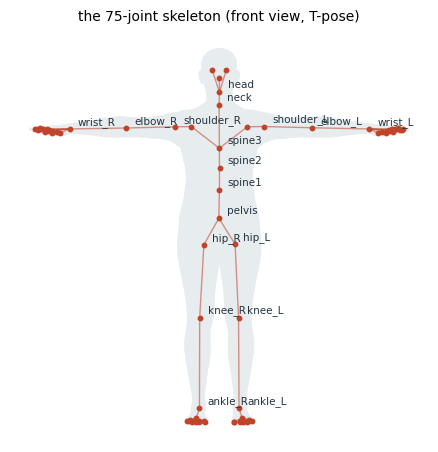

In [3]:
W_ = np.load(BODY_NPY, allow_pickle=True).item()["weights"]

def depth(j):
    n = 0
    while PARENT[j] >= 0:
        j = PARENT[j]; n += 1
    return n

print(f"{'name (indented by depth)':<28} {'j':>3} {'parent':>12} "
      f"{'pose numbers':>13} {'verts':>6}")
for j in range(75):
    par = NAME_OF[PARENT[j]] if PARENT[j] >= 0 else "-"
    label = "  " * depth(j) + NAME_OF[j]
    print(f"{label:<28} {j:3d} {par:>12} {f'{j*3}-{j*3+2}':>13} "
          f"{int((W_[:, j] > 0.5).sum()):6d}")
print(f"\ntotal {int((W_ > 0.5).sum())} of {model.num_verts} vertices are dominated by some joint")

fig, ax = plt.subplots(figsize=(5.4, 8.6))
order = np.argsort(NEUTRAL[FACES][:, :, 2].mean(axis=1))
ax.add_collection(PolyCollection(NEUTRAL[FACES][:, :, [0, 1]][order],
                                 facecolors="#E7ECEF", edgecolors="none"))
for j in range(75):
    p = PARENT[j]
    if p >= 0:
        ax.plot(NEUTRAL_J[[p, j], 0], NEUTRAL_J[[p, j], 1], "-", lw=1.0,
                color="#C0442A", alpha=.55, zorder=4)
ax.plot(NEUTRAL_J[:, 0], NEUTRAL_J[:, 1], "o", ms=3.2, color="#C0442A", zorder=5)
for name in BIG_JOINTS + ("pelvis",):
    j = JOINTS[name]
    ax.annotate(name, (NEUTRAL_J[j, 0], NEUTRAL_J[j, 1]), textcoords="offset points",
                xytext=(6, 3), fontsize=7.5, color="#22333F", zorder=6)
ax.set_aspect("equal"); ax.axis("off")
ax.set_title("the 75-joint skeleton (front view, T-pose)", fontsize=10)
plt.show()

## 4 — What the three axes of a joint do

Worth reading before you touch a slider. A limb rotates about its **own** axes, not the
world's, so what "pitch" does depends on which way the limb points.

The legs hang down the Y axis, so pitch swings them forward and back. The arms in a T-pose
point along X, so pitch merely **twists** them and roll is what lifts them. That surprises
everyone once.

In [4]:
def what_does_axis_do(joint, tracked, degrees=30):
    base = NEUTRAL_J[JOINTS[tracked]]
    print(f"'{joint}' bent {degrees} deg on each axis -- where '{tracked}' ends up:")
    for axis in AXES:
        _, J = body(**{f"{joint}_{axis}": degrees})
        d = (J[JOINTS[tracked]] - base) * UNIT_MM
        print(f"   {axis:5s}  outward {d[0]:+7.1f}   up {d[1]:+7.1f}   forward {d[2]:+7.1f} mm")

what_does_axis_do("shoulder_L", "wrist_L")
print()
what_does_axis_do("elbow_L", "wrist_L")
print()
what_does_axis_do("hip_R", "ankle_R")
print()
what_does_axis_do("knee_R", "ankle_R")

print("\nand the left/right sign trap:")
for axis in ("pitch", "roll"):
    dl = (body(**{f"shoulder_L_{axis}": -45})[1][JOINTS["wrist_L"]]
          - NEUTRAL_J[JOINTS["wrist_L"]])[1] * UNIT_MM
    dr = (body(**{f"shoulder_R_{axis}": -45})[1][JOINTS["wrist_R"]]
          - NEUTRAL_J[JOINTS["wrist_R"]])[1] * UNIT_MM
    same = "same direction" if dl * dr > 0 else "OPPOSITE directions"
    print(f"   shoulder {axis:5s} -45: left wrist {dl:+7.1f} mm, right {dr:+7.1f} mm  -> {same}")
print("   that is why mirror() flips the sign on yaw and roll but not on pitch")

'shoulder_L' bent 30 deg on each axis -- where 'wrist_L' ends up:
   pitch  outward    +0.0   up    +5.2   forward    -4.7 mm
   yaw    outward   -68.2   up    +0.0   forward  -240.1 mm
   roll   outward   -59.0   up  +242.6   forward    +0.0 mm

'elbow_L' bent 30 deg on each axis -- where 'wrist_L' ends up:
   pitch  outward    +0.0   up    +3.2   forward    -2.2 mm
   yaw    outward   -37.3   up    +0.0   forward  -129.3 mm
   roll   outward   -32.0   up  +130.8   forward    +0.0 mm

'hip_R' bent 30 deg on each axis -- where 'ankle_R' ends up:
   pitch  outward    +0.0   up  +135.6   forward  -365.3 mm
   yaw    outward   -32.5   up    -0.0   forward   +19.6 mm
   roll   outward  +377.5   up   +90.2   forward    -0.0 mm

'knee_R' bent 30 deg on each axis -- where 'ankle_R' ends up:
   pitch  outward    +0.0   up   +78.5   forward  -201.5 mm
   yaw    outward   -22.7   up    -0.0   forward    +6.7 mm
   roll   outward  +207.8   up   +55.1   forward    +0.0 mm

and the left/right sign 

## 5 — Play with it

Pick a joint, move its three axes. Your choices **accumulate**, so switch joints and keep
going to build up a pose. Switching back shows what that joint is currently set to.

*symmetric* mirrors every move onto the other side with the correct sign. *clear this joint*
zeroes only the one you are looking at.

In [5]:
import ipywidgets as W
from IPython.display import display

def explorer():
    style = {"description_width": "90px"}
    lay   = W.Layout(width="330px")
    POSE  = {}                          # {(joint, axis): degrees} -- accumulates

    pick = W.Dropdown(options=BIG_JOINTS + tuple(sorted(set(JOINTS) - set(BIG_JOINTS))),
                      value="shoulder_L", description="joint",
                      style=style, layout=W.Layout(width="260px"))
    sym  = W.Checkbox(value=True, description="symmetric")
    axis_sliders = {a: W.FloatSlider(value=0, min=-120, max=120, step=1, description=a,
                                     continuous_update=False, style=style, layout=lay,
                                     readout_format=".0f") for a in AXES}
    betas = [W.FloatSlider(value=0, min=-5, max=5, step=0.1, description=BETA_LABELS[i],
                           continuous_update=False, style={"description_width": "195px"},
                           layout=W.Layout(width="405px")) for i in range(6)]
    preset  = W.Dropdown(options=["-"] + list(RECIPES), value="-", description="preset",
                         style=style, layout=W.Layout(width="260px"))
    clear_j = W.Button(description="clear this joint", icon="eraser",
                       layout=W.Layout(width="150px"))
    reset   = W.Button(description="reset all", icon="undo", layout=W.Layout(width="120px"))
    out     = W.Output()
    fig = make_view(NEUTRAL)
    guard = {"on": False}

    def other_side(joint):
        if joint.endswith("_L"): return joint[:-2] + "_R"
        if joint.endswith("_R"): return joint[:-2] + "_L"
        return None

    def kwargs():
        return {f"{j}_{a}": v for (j, a), v in POSE.items() if v}

    def beta_dict():
        return {i: s.value for i, s in enumerate(betas) if s.value}

    def redraw():
        kw, b = kwargs(), beta_dict()
        V, J = body(betas=b or None, **kw)
        update_view(fig, V, J)
        with out:
            out.clear_output(wait=True)
            shown = ", ".join(f"{k}={v:g}" for k, v in sorted(kw.items()))
            print("body(" + (f"betas={b}, " if b else "") + shown + ")")
            report(V, "current", J, b or None)

    def on_axis(change):
        if guard["on"]:
            return
        joint = pick.value
        for a, s in axis_sliders.items():
            POSE[(joint, a)] = s.value
            twin = other_side(joint)
            if sym.value and twin:
                flip = -1.0 if a in MIRRORED_AXES else 1.0
                POSE[(twin, a)] = s.value * flip
        redraw()

    def load_joint(_=None):
        guard["on"] = True
        for a, s in axis_sliders.items():
            s.value = POSE.get((pick.value, a), 0.0)
        guard["on"] = False

    def on_preset(_):
        if preset.value == "-":
            return
        POSE.clear()
        for k, v in RECIPES[preset.value].items():
            j, _, a = k.rpartition("_")
            POSE[(j, a)] = v
        load_joint(); redraw()

    def on_clear(_):
        joint = pick.value
        for a in AXES:
            POSE.pop((joint, a), None)
            twin = other_side(joint)
            if sym.value and twin:
                POSE.pop((twin, a), None)
        load_joint(); redraw()

    def on_reset(_):
        preset.unobserve(on_preset, names="value")
        preset.value = "-"
        preset.observe(on_preset, names="value")
        POSE.clear()
        for s in betas: s.value = 0
        load_joint(); redraw()

    for s in axis_sliders.values(): s.observe(on_axis, names="value")
    for s in betas:                 s.observe(lambda _: redraw(), names="value")
    pick.observe(load_joint, names="value")
    preset.observe(on_preset, names="value")
    clear_j.on_click(on_clear); reset.on_click(on_reset)

    display(W.VBox([
        W.HBox([pick, sym, clear_j, reset]),
        W.HBox(list(axis_sliders.values())),
        W.HTML("<b>shape &mdash; the six betas that do the most</b>"),
        W.HBox([W.VBox(betas[:3]), W.VBox(betas[3:])]),
        W.HBox([preset]),
        fig, out]))
    redraw()

explorer()

## 6 — Which parameters give which pose

`bbox` is the posed bounding-box height, which is why sitting is short. `stature` is the
T-pose height for that body shape and does not move with pose -- that is the point of
measuring it separately.

In [6]:
print(f"{'pose':22s} {'bbox':>8} {'stature':>8} {'chest':>7} {'stretch':>8}   parameters")
for name, kw in RECIPES.items():
    V, J = body(**kw)
    m = measure(V, J)
    shown = ", ".join(f"{k}={v:g}" for k, v in sorted(kw.items()))
    print(f"{name:22s} {m['bbox_height_mm']:8.1f} {m['stature_mm']:8.1f} "
          f"{m['chest_girth_mm']:7.1f} {m['stretch_p99']:8.2f}   "
          + (shown[:64] + ("..." if len(shown) > 64 else "") if shown else "everything 0"))

pose                       bbox  stature   chest  stretch   parameters
T-pose (neutral)         1719.9   1719.9  1038.6     1.00   everything 0
A-pose                   1719.9   1719.9  1038.6     1.15   shoulder_L_roll=-45, shoulder_R_roll=45
arms at sides            1719.9   1719.9  1038.6     1.24   shoulder_L_roll=-72, shoulder_R_roll=72
arms straight up         2011.4   1719.9  1038.6     1.31   shoulder_L_roll=78, shoulder_R_roll=-78
arms forward             1719.9   1719.9  1038.6     1.38   shoulder_L_yaw=-80, shoulder_R_yaw=80
elbows bent              1719.9   1719.9  1038.6     1.29   elbow_L_roll=80, elbow_R_roll=-80, shoulder_L_roll=-55, shoulder...
sitting                  1439.5   1719.9  1038.6     1.44   hip_L_pitch=-85, hip_R_pitch=-85, knee_L_pitch=85, knee_R_pitch=...
deep squat               1382.6   1719.9  1038.6     1.47   hip_L_pitch=-95, hip_R_pitch=-95, knee_L_pitch=115, knee_R_pitch...
walking stride           1685.0   1719.9  1038.6     1.29   hip_L_pitch=-2

## 7 — What the betas do

400 shape numbers are available and we load 100. Only the first handful matter, and beta 0 is
overall size, which is why it moves every measurement at once.

In [7]:
print(f"{'':6}" + "".join(f"{n:>10}" for n in _DIM_NAMES) + "   what it mostly does")
print(f"{'':6}" + "".join(f"{'mm':>10}" for _ in _DIM_NAMES))
print(f"{'base':6}" + "".join(f"{v:10.1f}" for v in _BASE_DIMS))
for i in range(10):
    V, J = body(betas={i: 2.0})
    d = _dims_mm(V, J) - _BASE_DIMS
    lab = beta_label(i).split("\u2014")[1].strip()
    print(f"b{i:<5}" + "".join(f"{v:+10.1f}" for v in d) + f"   {lab}")
print("\n(each row is that beta set to +2, everything else 0; numbers are change from base)")

S = np.asarray(np.load(BODY_NPY, allow_pickle=True).item()["shapedirs"])
reach = np.linalg.norm(S, axis=1).max(axis=0) * UNIT_MM
print(f"\nfarthest a single vertex moves per 1.0 of each beta:")
for i in range(8):
    print(f"   beta {i}: {reach[i]:6.2f} mm")
print(f"   ...\n   beta 50: {reach[50]:6.2f} mm     beta 99: {reach[99]:6.2f} mm"
      f"     beta 399: {reach[399]:6.2f} mm")
print(f"\nfirst 10 betas carry {100*reach[:10].sum()/reach.sum():.0f}% of the total reach, "
      f"first 100 carry {100*reach[:100].sum()/reach.sum():.0f}%.")

         stature     chest     waist       hip       leg   what it mostly does
              mm        mm        mm        mm        mm
base      1719.9    1038.6     896.3    1034.7     753.4
b0          +0.0      +0.0      +0.0      +0.0     +82.0   longer / shorter legs
b1          +0.0      +0.0      +0.0      +0.0      +7.2   longer / shorter legs
b2          +0.0      +0.0      +0.0      +0.0     -28.2   longer / shorter legs
b3          +0.0      +0.0      +0.0      +0.0     +14.4   longer / shorter legs
b4          +0.0      +0.0      +0.0      +0.0      +7.9   longer / shorter legs
b5          +0.0      +0.0      +0.0      +0.0      -3.4   longer / shorter legs
b6          +0.0      +0.0      +0.0      +0.0     +18.2   longer / shorter legs
b7          +0.0      +0.0      +0.0      +0.0      +5.9   longer / shorter legs
b8          +0.0      +0.0      +0.0      +0.0      -3.2   longer / shorter legs
b9          +0.0      +0.0      +0.0      +0.0      +2.2   longer / shorter le

## 8 — The girth profile

How thick the body is at every height. This is the curve garment and footwear work actually
cares about, and it is measured by intersecting triangles with a plane, not by binning
vertices.

It stops below the armpits: a horizontal cut at shoulder height slices the arms too, and the
number stops meaning anything.

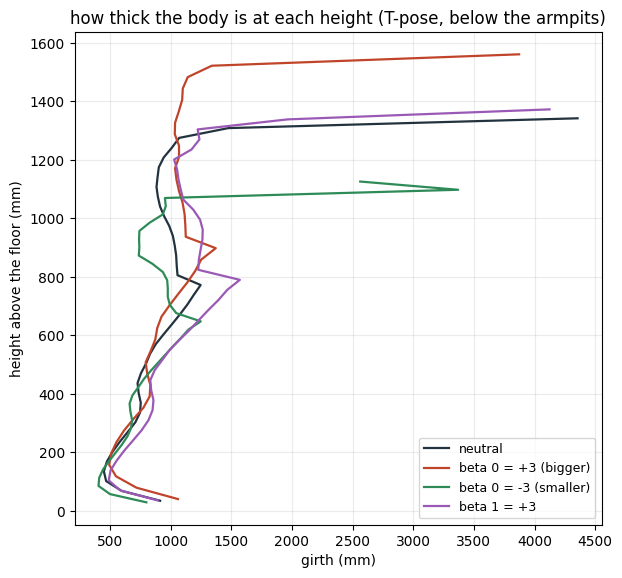

neutral body, every station (mm):
   neck       387.1
   chest     1038.6
   waist      896.3
   hip       1034.7
   thigh      611.0
   calf       377.0
   ankle      240.2

   stature 1719.9   arm span 1743.9   shoulder width 408.1
   arm 482.2   leg 753.4

Thigh, calf and ankle are the RIGHT leg only -- a horizontal plane cuts both legs,
so those cuts are filtered to one side.


In [8]:
fig, ax = plt.subplots(figsize=(6.8, 6.4))
CASES = [("neutral",                    None,       "#22333F"),
         ("beta 0 = +3 (bigger)",       {0: 3.0},   "#C0442A"),
         ("beta 0 = -3 (smaller)",      {0: -3.0},  "#2E8B57"),
         ("beta 1 = +3",                {1: 3.0},   "#9B59B6")]
for name, b, colour in CASES:
    V, J = body(betas=b)
    g = girth_profile(V)
    ax.plot(g[:, 1], g[:, 0], "-", lw=1.6, color=colour, label=name)
ax.set_xlabel("girth (mm)"); ax.set_ylabel("height above the floor (mm)")
ax.set_title("how thick the body is at each height (T-pose, below the armpits)")
ax.grid(alpha=.25); ax.legend(fontsize=9)

m = measure(NEUTRAL, NEUTRAL_J)
for name, colour in (("ankle", "#888"), ("calf", "#888"), ("thigh", "#888"),
                     ("hip", "#888"), ("waist", "#888"), ("chest", "#888")):
    ax.annotate(f"{name} {m[name + '_girth_mm']:.0f}", xy=(0.02, 0.02), xycoords="axes fraction",
                alpha=0)   # keep the legend clean; the numbers are printed below
plt.show()

print("neutral body, every station (mm):")
for name in ("neck", "chest", "waist", "hip", "thigh", "calf", "ankle"):
    print(f"   {name:8s} {m[name + '_girth_mm']:7.1f}")
print(f"\n   stature {m['stature_mm']:.1f}   arm span {m['arm_span_mm']:.1f}   "
      f"shoulder width {m['shoulder_w_mm']:.1f}")
print(f"   arm {m['arm_mm']:.1f}   leg {m['leg_mm']:.1f}")
print("\nThigh, calf and ankle are the RIGHT leg only -- a horizontal plane cuts both legs,")
print("so those cuts are filtered to one side.")

## 9 — Export

In [9]:
from pathlib import Path

def export(V, name, out=f"{REPO}/output/supr_explorer"):
    """Write the current body as PLY and OBJ, same folder as the other explorer output."""
    Path(out).mkdir(parents=True, exist_ok=True)
    p = Path(out) / f"{name}.ply"
    with open(p, "w") as f:
        f.write(f"ply\nformat ascii 1.0\nelement vertex {len(V)}\n")
        f.write("property float x\nproperty float y\nproperty float z\n")
        f.write(f"element face {len(FACES)}\nproperty list uchar int vertex_indices\n")
        f.write("end_header\n")
        for v in V:
            f.write(f"{v[0]:.6f} {v[1]:.6f} {v[2]:.6f}\n")
        for t in FACES:
            f.write(f"3 {t[0]} {t[1]} {t[2]}\n")
    o = Path(out) / f"{name}.obj"
    with open(o, "w") as f:
        for v in V:
            f.write(f"v {v[0]:.6f} {v[1]:.6f} {v[2]:.6f}\n")
        for t in FACES:
            f.write(f"f {t[0]+1} {t[1]+1} {t[2]+1}\n")
    print(f"wrote {p}\n      {o}")
    return p, o

# export(body(**RECIPES["A-pose"])[0], "body_apose")

## 10 — Scratch

Yours. `body(...)`, `mirror(...)`, `report(...)`, `show(...)`, `make_view(...)`,
`girth_profile(...)`, `what_does_axis_do(...)` and `JOINTS` are all loaded.